In [1]:
# =============================================================================
# Notebook 02 — Análise Temporal Aprofundada
# Sistema de Painéis Hospitalares — Central de ML
# =============================================================================
# Objetivos:
#   1. Decomposição sazonal (tendência / semana / ano / resíduo)
#   2. Investigação do surto de 2024 (dengue)
#   3. Análise de feriados brasileiros
#   4. Integração com clima histórico (Open-Meteo)
#   5. Análise de lags (autocorrelação)
#   6. Lista final de features para o modelo
# =============================================================================

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas específicas do notebook 02
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import holidays
import requests

# Visual
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"statsmodels: carregado")
print(f"holidays: carregado")
print("Setup OK")

Python: 3.11.9
pandas: 2.2.3
statsmodels: carregado
holidays: carregado
Setup OK


In [2]:
# =============================================================================
# Carrega o dataset do Parquet gerado no Notebook 01 (muito mais rápido)
# =============================================================================

df = pd.read_parquet('../data/ml_ps_historico_chegadas.parquet')
print(f"Linhas carregadas: {len(df):,}")
print(f"Período: {df['dt_entrada'].min()} até {df['dt_entrada'].max()}")

Linhas carregadas: 236,864
Período: 2023-07-14 03:34:10 até 2026-04-09 01:41:06


In [3]:
# =============================================================================
# Cria a série temporal diária que vai ser usada em todas as análises abaixo
# IMPORTANTE: excluímos o último dia porque está incompleto (ETL rodou de madrugada)
# =============================================================================

# Agrupa por data
chegadas_diarias = df.groupby(df['dt_entrada'].dt.date).size().reset_index(name='chegadas')
chegadas_diarias.columns = ['data', 'chegadas']
chegadas_diarias['data'] = pd.to_datetime(chegadas_diarias['data'])

# Remove o último dia (incompleto)
ultimo_dia = chegadas_diarias['data'].max()
chegadas_diarias = chegadas_diarias[chegadas_diarias['data'] < ultimo_dia].copy()

# Define data como índice (statsmodels precisa disso pra decomposição)
chegadas_diarias = chegadas_diarias.set_index('data').asfreq('D')

print(f"Série temporal diária:")
print(f"  Início: {chegadas_diarias.index.min().date()}")
print(f"  Fim:    {chegadas_diarias.index.max().date()}")
print(f"  Dias:   {len(chegadas_diarias)}")
print(f"  Nulos:  {chegadas_diarias['chegadas'].isna().sum()}")
print(f"  Média:  {chegadas_diarias['chegadas'].mean():.1f} chegadas/dia")

Série temporal diária:
  Início: 2023-07-14
  Fim:    2026-04-08
  Dias:   1000
  Nulos:  0
  Média:  236.9 chegadas/dia


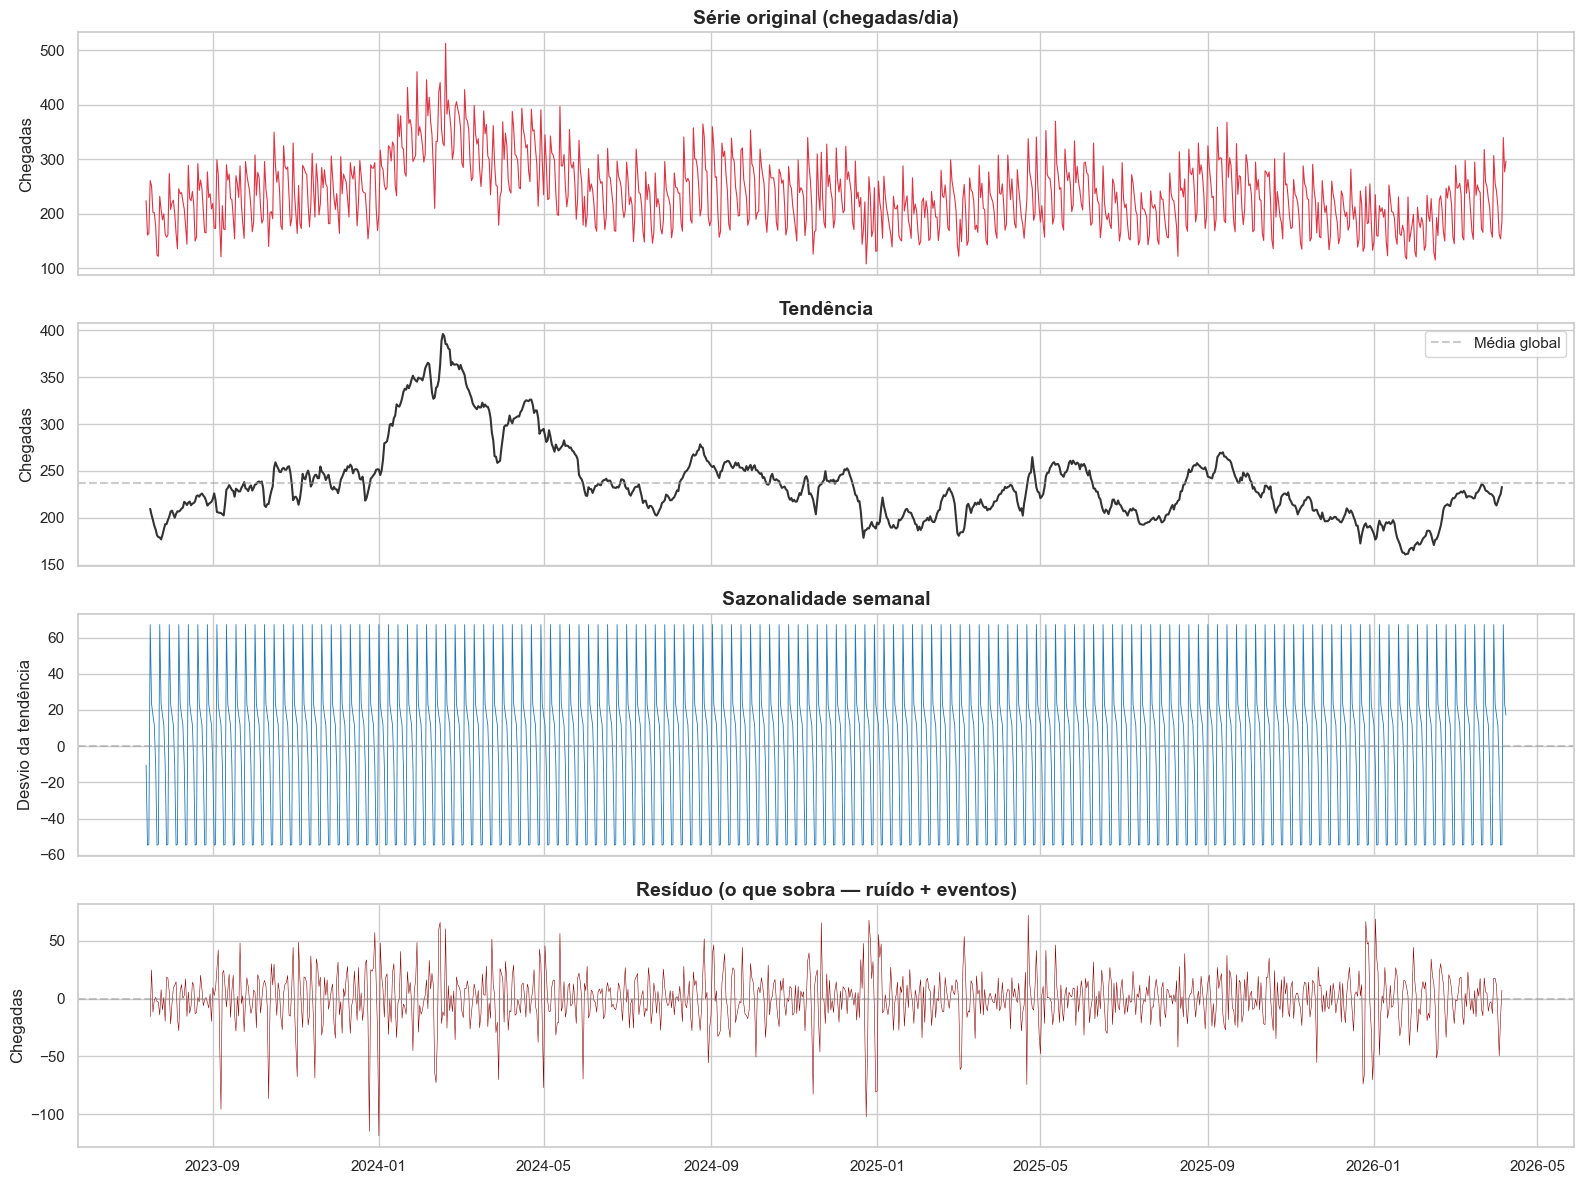


Força da sazonalidade semanal (amplitude): 121.8 chegadas
Variabilidade da tendência: 41.4
Desvio padrão do resíduo: 22.2


In [4]:
# =============================================================================
# Decomposição aditiva com período semanal (7 dias)
# Separa a série em: tendência + sazonalidade semanal + resíduo
# =============================================================================

decomp_semanal = seasonal_decompose(chegadas_diarias['chegadas'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(chegadas_diarias.index, chegadas_diarias['chegadas'],
             color='#dc3545', linewidth=0.8)
axes[0].set_title('Série original (chegadas/dia)', fontweight='bold')
axes[0].set_ylabel('Chegadas')

axes[1].plot(decomp_semanal.trend.index, decomp_semanal.trend,
             color='#333', linewidth=1.5)
axes[1].set_title('Tendência', fontweight='bold')
axes[1].set_ylabel('Chegadas')
axes[1].axhline(chegadas_diarias['chegadas'].mean(), color='#999',
                linestyle='--', alpha=0.5, label='Média global')
axes[1].legend()

axes[2].plot(decomp_semanal.seasonal.index, decomp_semanal.seasonal,
             color='#1f77b4', linewidth=0.6)
axes[2].set_title('Sazonalidade semanal', fontweight='bold')
axes[2].set_ylabel('Desvio da tendência')
axes[2].axhline(0, color='#999', linestyle='--', alpha=0.5)

axes[3].plot(decomp_semanal.resid.index, decomp_semanal.resid,
             color='#8b0000', linewidth=0.4)
axes[3].set_title('Resíduo (o que sobra — ruído + eventos)', fontweight='bold')
axes[3].set_ylabel('Chegadas')
axes[3].axhline(0, color='#999', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nForça da sazonalidade semanal (amplitude): {decomp_semanal.seasonal.max() - decomp_semanal.seasonal.min():.1f} chegadas")
print(f"Variabilidade da tendência: {decomp_semanal.trend.std():.1f}")
print(f"Desvio padrão do resíduo: {decomp_semanal.resid.std():.1f}")

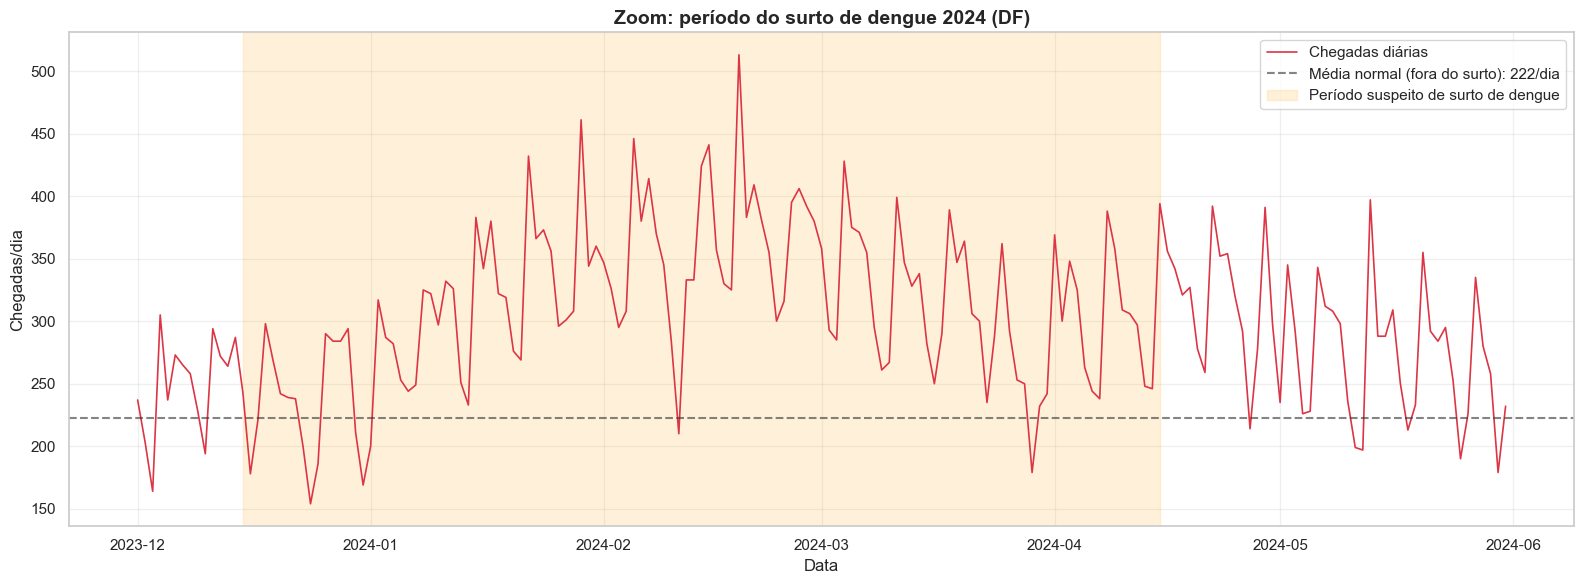


Estatísticas do período dez/2023 — mai/2024:
  Média:   301.2 chegadas/dia
  Máximo:  513 (2024-02-19)
  Mínimo:  154 (2023-12-24)

Média do resto do histórico: 222.4
Excesso médio durante o surto: +78.8 chegadas/dia (35%)


In [5]:
# =============================================================================
# Zoom no período de dez/2023 a mai/2024 — o surto de dengue do DF
# =============================================================================

periodo_surto = chegadas_diarias['2023-12-01':'2024-05-31'].copy()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(periodo_surto.index, periodo_surto['chegadas'],
        color='#dc3545', linewidth=1.2, label='Chegadas diárias')

# Média global do período normal pra comparação
media_normal = chegadas_diarias[~((chegadas_diarias.index >= '2023-12-01') &
                                   (chegadas_diarias.index <= '2024-05-31'))]['chegadas'].mean()
ax.axhline(media_normal, color='#333', linestyle='--', alpha=0.6,
           label=f'Média normal (fora do surto): {media_normal:.0f}/dia')

# Marca área do surto
ax.axvspan('2023-12-15', '2024-04-15', alpha=0.15, color='orange',
           label='Período suspeito de surto de dengue')

ax.set_title('Zoom: período do surto de dengue 2024 (DF)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Chegadas/dia')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas comparativas
stats_surto = periodo_surto['chegadas']
print(f"\nEstatísticas do período dez/2023 — mai/2024:")
print(f"  Média:   {stats_surto.mean():.1f} chegadas/dia")
print(f"  Máximo:  {stats_surto.max()} ({stats_surto.idxmax().date()})")
print(f"  Mínimo:  {stats_surto.min()} ({stats_surto.idxmin().date()})")
print(f"\nMédia do resto do histórico: {media_normal:.1f}")
print(f"Excesso médio durante o surto: +{stats_surto.mean() - media_normal:.1f} chegadas/dia ({(stats_surto.mean()/media_normal - 1)*100:.0f}%)")

In [6]:
# =============================================================================
# Cria flag booleana para marcar o período do surto
# Esta flag vai entrar como feature no modelo
# =============================================================================

# Janela do surto — vamos usar 15/dez/2023 a 15/abr/2024 baseado no zoom
INICIO_SURTO = '2023-12-15'
FIM_SURTO = '2024-04-15'

chegadas_diarias['flag_surto_dengue_2024'] = (
    (chegadas_diarias.index >= INICIO_SURTO) &
    (chegadas_diarias.index <= FIM_SURTO)
).astype(int)

dias_surto = chegadas_diarias['flag_surto_dengue_2024'].sum()
print(f"Flag criada: {dias_surto} dias marcados como surto")
print(f"Média durante surto: {chegadas_diarias[chegadas_diarias['flag_surto_dengue_2024']==1]['chegadas'].mean():.1f}")
print(f"Média fora do surto: {chegadas_diarias[chegadas_diarias['flag_surto_dengue_2024']==0]['chegadas'].mean():.1f}")

Flag criada: 123 dias marcados como surto
Média durante surto: 313.0
Média fora do surto: 226.2


In [7]:
# =============================================================================
# Marca feriados nacionais e do DF usando a biblioteca holidays
# =============================================================================

# Feriados nacionais + DF
anos = list(range(chegadas_diarias.index.year.min(), chegadas_diarias.index.year.max() + 1))
feriados_br = holidays.Brazil(years=anos, subdiv='DF')

print(f"Feriados carregados para {anos}:")
for data, nome in sorted(feriados_br.items()):
    if chegadas_diarias.index.min().date() <= data <= chegadas_diarias.index.max().date():
        print(f"  {data}: {nome}")

# Flags
chegadas_diarias['is_feriado'] = chegadas_diarias.index.to_series().apply(
    lambda d: d.date() in feriados_br
).astype(int)

# Dia antes e dia depois de feriado (muitas vezes também afetam volume)
feriado_datas = set(feriados_br.keys())
chegadas_diarias['is_vespera_feriado'] = chegadas_diarias.index.to_series().apply(
    lambda d: (d.date() + timedelta(days=1)) in feriado_datas
).astype(int)
chegadas_diarias['is_pos_feriado'] = chegadas_diarias.index.to_series().apply(
    lambda d: (d.date() - timedelta(days=1)) in feriado_datas
).astype(int)

print(f"\nDias de feriado no histórico: {chegadas_diarias['is_feriado'].sum()}")
print(f"Dias de véspera de feriado:  {chegadas_diarias['is_vespera_feriado'].sum()}")
print(f"Dias pós-feriado:            {chegadas_diarias['is_pos_feriado'].sum()}")

Feriados carregados para [2023, 2024, 2025, 2026]:
  2023-09-07: Independência do Brasil
  2023-10-12: Nossa Senhora Aparecida
  2023-11-02: Finados
  2023-11-15: Proclamação da República
  2023-11-30: Dia do Evangélico
  2023-12-25: Natal
  2024-01-01: Confraternização Universal
  2024-03-29: Sexta-feira Santa
  2024-04-21: Fundação de Brasília; Tiradentes
  2024-05-01: Dia do Trabalhador
  2024-09-07: Independência do Brasil
  2024-10-12: Nossa Senhora Aparecida
  2024-11-02: Finados
  2024-11-15: Proclamação da República
  2024-11-20: Dia Nacional de Zumbi e da Consciência Negra
  2024-11-30: Dia do Evangélico
  2024-12-25: Natal
  2025-01-01: Confraternização Universal
  2025-04-18: Sexta-feira Santa
  2025-04-21: Fundação de Brasília; Tiradentes
  2025-05-01: Dia do Trabalhador
  2025-09-07: Independência do Brasil
  2025-10-12: Nossa Senhora Aparecida
  2025-11-02: Finados
  2025-11-15: Proclamação da República
  2025-11-20: Dia Nacional de Zumbi e da Consciência Negra
  2025-11-

COMPARAÇÃO — Tipo de dia vs volume (excluindo período de surto)
               count   mean   std  min  max
tipo_dia                                   
Dia útil         610  250.1  44.2  108  397
Feriado           27  172.1  33.2  121  259
Fim de semana    240  171.4  24.9  115  278


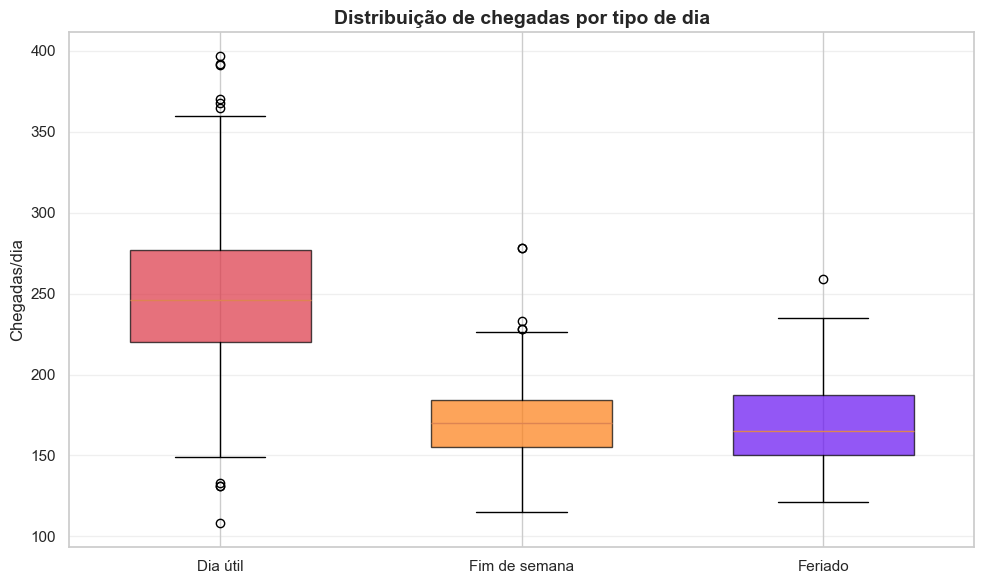

In [8]:
# =============================================================================
# Descobrir se feriado enche ou esvazia o PS do HAC
# =============================================================================

df_comp = chegadas_diarias.copy()
df_comp['dia_semana'] = df_comp.index.dayofweek  # 0=segunda, 6=domingo
df_comp['tipo_dia'] = 'Dia útil'
df_comp.loc[df_comp['dia_semana'] >= 5, 'tipo_dia'] = 'Fim de semana'
df_comp.loc[df_comp['is_feriado'] == 1, 'tipo_dia'] = 'Feriado'

# Remove período de surto pra não contaminar comparação
df_comp_clean = df_comp[df_comp['flag_surto_dengue_2024'] == 0]

resumo = df_comp_clean.groupby('tipo_dia')['chegadas'].agg(['count', 'mean', 'std', 'min', 'max']).round(1)
print("COMPARAÇÃO — Tipo de dia vs volume (excluindo período de surto)")
print("=" * 70)
print(resumo)

fig, ax = plt.subplots(figsize=(10, 6))
ordem = ['Dia útil', 'Fim de semana', 'Feriado']
colors = ['#dc3545', '#fd7e14', '#6610f2']
data_box = [df_comp_clean[df_comp_clean['tipo_dia']==t]['chegadas'].values for t in ordem]
bp = ax.boxplot(data_box, labels=ordem, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribuição de chegadas por tipo de dia',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Chegadas/dia')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# Busca histórico climático de Ceilândia via Open-Meteo (gratuito, sem API key)
# Documentação: https://open-meteo.com/en/docs/historical-weather-api
# =============================================================================

# Coordenadas do Hospital Anchieta Ceilândia
LAT = -15.82
LON = -48.11

data_inicio = chegadas_diarias.index.min().strftime('%Y-%m-%d')
data_fim = chegadas_diarias.index.max().strftime('%Y-%m-%d')

print(f"Buscando clima de Ceilândia de {data_inicio} até {data_fim}...")

url = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude': LAT,
    'longitude': LON,
    'start_date': data_inicio,
    'end_date': data_fim,
    'daily': ','.join([
        'temperature_2m_max',
        'temperature_2m_min',
        'temperature_2m_mean',
        'precipitation_sum',
        'rain_sum',
        'precipitation_hours',
        'windspeed_10m_max',
        'relative_humidity_2m_mean',
    ]),
    'timezone': 'America/Sao_Paulo'
}

response = requests.get(url, params=params, timeout=60)
response.raise_for_status()
dados = response.json()

clima = pd.DataFrame(dados['daily'])
clima['time'] = pd.to_datetime(clima['time'])
clima = clima.set_index('time')
clima.index.name = 'data'

# Renomeia pra nomes mais curtos e em português
clima = clima.rename(columns={
    'temperature_2m_max': 'temp_max',
    'temperature_2m_min': 'temp_min',
    'temperature_2m_mean': 'temp_media',
    'precipitation_sum': 'precipitacao_mm',
    'rain_sum': 'chuva_mm',
    'precipitation_hours': 'horas_chuva',
    'windspeed_10m_max': 'vento_max',
    'relative_humidity_2m_mean': 'umidade_media',
})

print(f"\n[OK] Clima baixado: {len(clima)} dias")
print(f"Colunas: {list(clima.columns)}")
print(f"\nPrimeiras linhas:")
print(clima.head())

# Salva em parquet separado pra não precisar baixar de novo
os.makedirs('../data', exist_ok=True)
clima.to_parquet('../data/clima_ceilandia.parquet')
print(f"\n[OK] Salvo em ../data/clima_ceilandia.parquet")

Buscando clima de Ceilândia de 2023-07-14 até 2026-04-08...

[OK] Clima baixado: 1000 dias
Colunas: ['temp_max', 'temp_min', 'temp_media', 'precipitacao_mm', 'chuva_mm', 'horas_chuva', 'vento_max', 'umidade_media']

Primeiras linhas:
            temp_max  temp_min  temp_media  precipitacao_mm  chuva_mm  \
data                                                                    
2023-07-14      23.2      12.8        18.4              0.0       0.0   
2023-07-15      26.7      14.1        19.9              0.0       0.0   
2023-07-16      26.7      16.1        21.3              0.0       0.0   
2023-07-17      26.1      17.3        21.4              0.0       0.0   
2023-07-18      26.9      17.9        21.8              0.0       0.0   

            horas_chuva  vento_max  umidade_media  
data                                               
2023-07-14          0.0       15.3             61  
2023-07-15          0.0       18.1             56  
2023-07-16          0.0       17.1            

Linhas após merge: 1000
Nulos em temp_media: 0


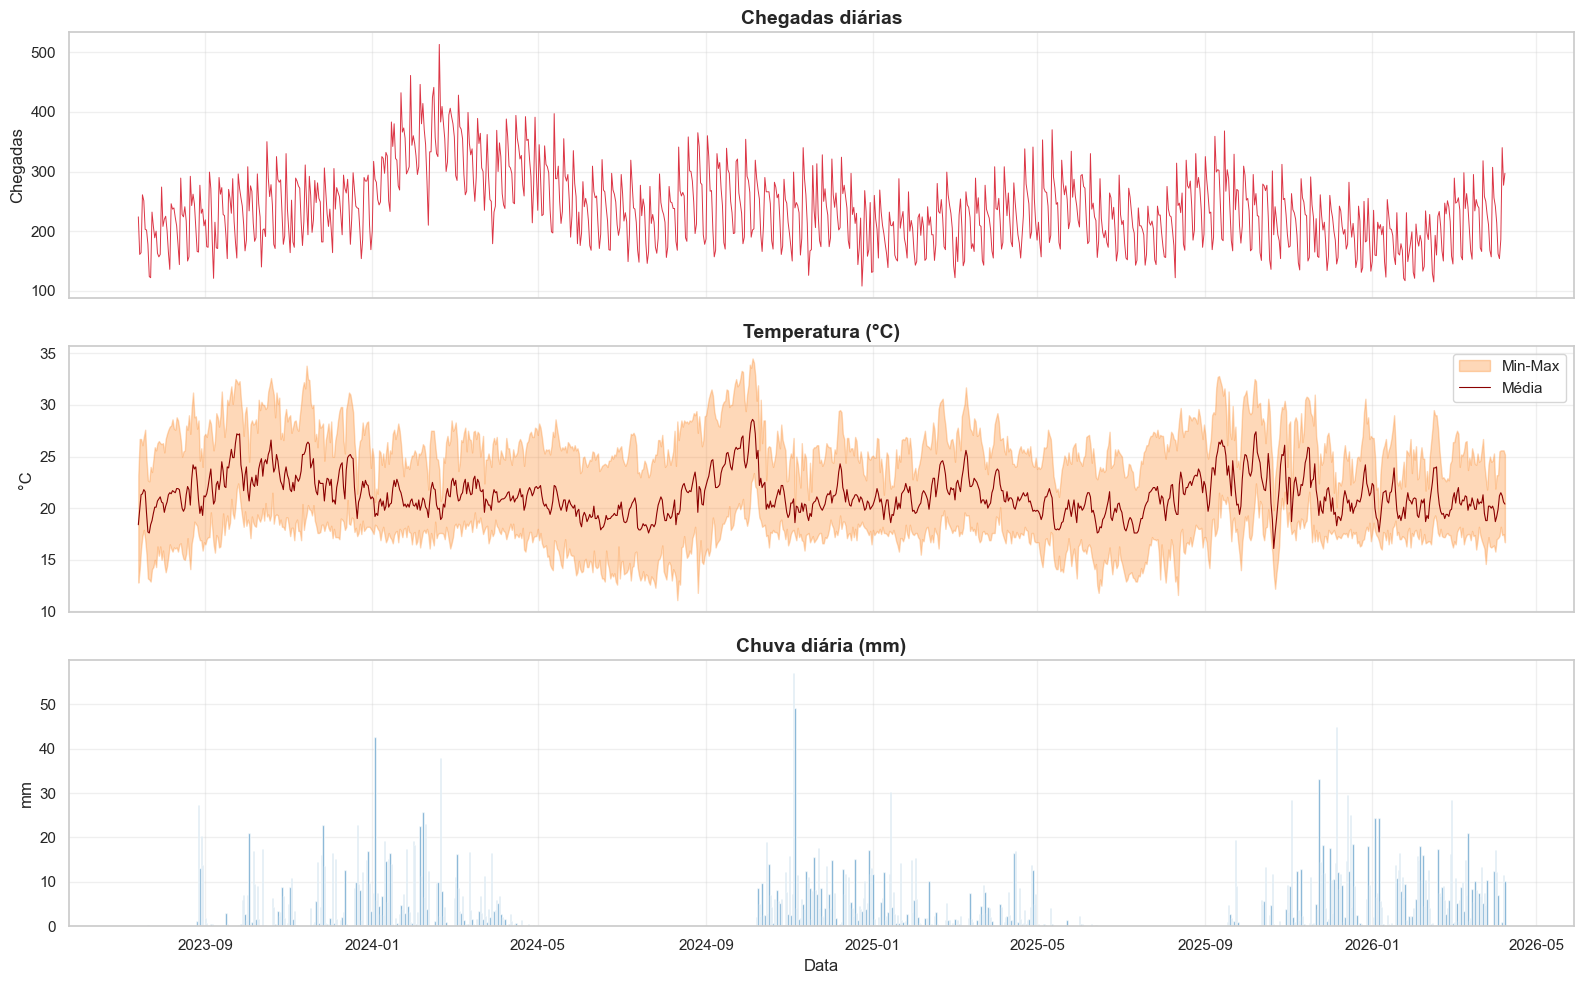

In [10]:
# =============================================================================
# Merge clima com chegadas e visualiza sobreposto
# =============================================================================

# Merge
df_completo = chegadas_diarias.join(clima, how='left')
print(f"Linhas após merge: {len(df_completo)}")
print(f"Nulos em temp_media: {df_completo['temp_media'].isna().sum()}")

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Chegadas
axes[0].plot(df_completo.index, df_completo['chegadas'],
             color='#dc3545', linewidth=0.7)
axes[0].set_title('Chegadas diárias', fontweight='bold')
axes[0].set_ylabel('Chegadas')
axes[0].grid(True, alpha=0.3)

# Temperatura
axes[1].fill_between(df_completo.index, df_completo['temp_min'], df_completo['temp_max'],
                     alpha=0.3, color='#fd7e14', label='Min-Max')
axes[1].plot(df_completo.index, df_completo['temp_media'],
             color='#8b0000', linewidth=0.8, label='Média')
axes[1].set_title('Temperatura (°C)', fontweight='bold')
axes[1].set_ylabel('°C')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chuva
axes[2].bar(df_completo.index, df_completo['chuva_mm'],
            color='#1f77b4', alpha=0.7, width=1.0)
axes[2].set_title('Chuva diária (mm)', fontweight='bold')
axes[2].set_ylabel('mm')
axes[2].set_xlabel('Data')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Correlação entre volume de chegadas e variáveis climáticas
(período de surto excluído)
  temp_max             +0.170  (MODERADA)
  horas_chuva          -0.170  (MODERADA)
  umidade_media        -0.154  (MODERADA)
  temp_media           +0.137  (FRACA)
  precipitacao_mm      -0.089  (FRACA)
  chuva_mm             -0.089  (FRACA)
  vento_max            +0.081  (FRACA)
  temp_min             +0.040  (FRACA)


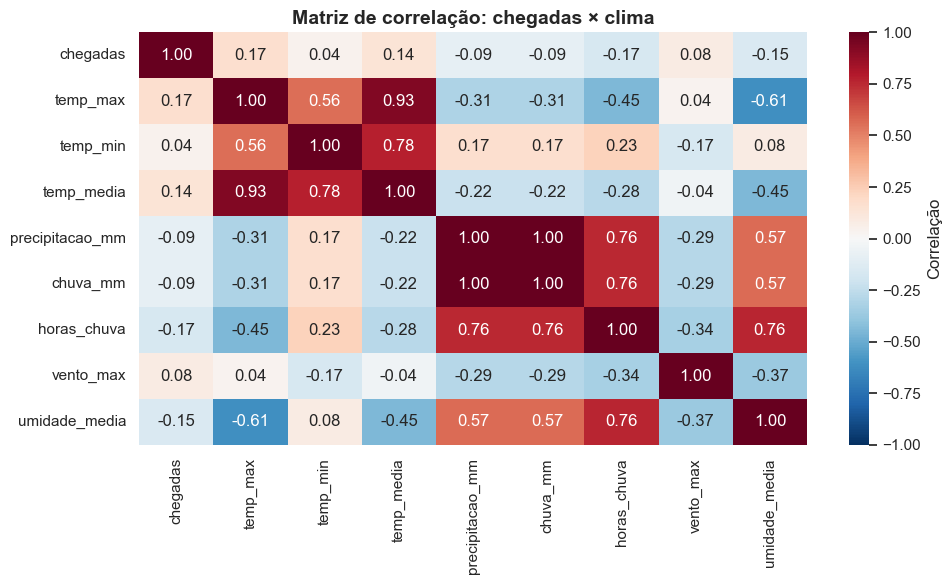

In [11]:
# =============================================================================
# Qual variável climática se correlaciona mais com volume de chegadas?
# =============================================================================

# Remove período de surto pra não poluir correlação
df_corr = df_completo[df_completo['flag_surto_dengue_2024'] == 0].copy()

variaveis_clima = ['temp_max', 'temp_min', 'temp_media', 'precipitacao_mm',
                   'chuva_mm', 'horas_chuva', 'vento_max', 'umidade_media']

correlacoes = df_corr[['chegadas'] + variaveis_clima].corr()['chegadas'].drop('chegadas')
correlacoes_sorted = correlacoes.sort_values(key=abs, ascending=False)

print("Correlação entre volume de chegadas e variáveis climáticas")
print("(período de surto excluído)")
print("=" * 55)
for var, corr in correlacoes_sorted.items():
    sinal = '+' if corr > 0 else '-'
    forca = 'FORTE' if abs(corr) > 0.3 else ('MODERADA' if abs(corr) > 0.15 else 'FRACA')
    print(f"  {var:20s} {sinal}{abs(corr):.3f}  ({forca})")

# Heatmap visual
fig, ax = plt.subplots(figsize=(10, 6))
corr_matrix = df_corr[['chegadas'] + variaveis_clima].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Correlação'})
ax.set_title('Matriz de correlação: chegadas × clima', fontweight='bold')
plt.tight_layout()
plt.show()

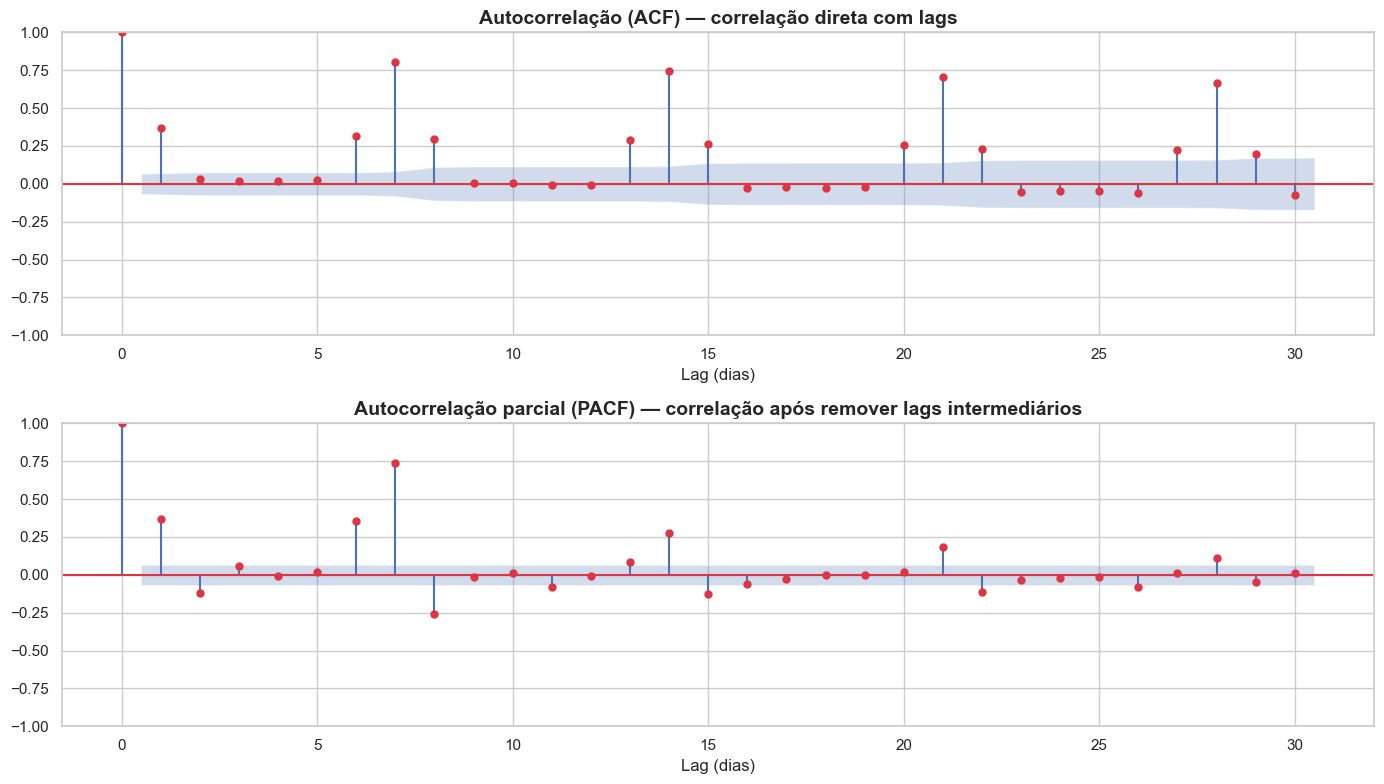


Interpretação:
- Picos em lag 7, 14, 21 → sazonalidade semanal forte (já esperado)
- PACF alto em lag 1 → o dia anterior prediz bem o próximo
- PACF alto em lag 7 → o mesmo dia da semana anterior também prediz

Features de lag a criar no próximo notebook:
  - lag_1d  (ontem)
  - lag_7d  (mesmo dia semana passada)
  - lag_14d (mesmo dia há duas semanas)
  - media_movel_7d (últimos 7 dias)
  - media_movel_28d (últimos 28 dias — tendência mensal)


In [12]:
# =============================================================================
# Quais "janelas do passado" predizem o futuro?
# ACF = autocorrelation function
# PACF = partial autocorrelation function
# =============================================================================

# Usa série sem surto pra não distorcer
serie_limpa = df_completo[df_completo['flag_surto_dengue_2024'] == 0]['chegadas']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_limpa, lags=30, ax=axes[0], color='#dc3545')
axes[0].set_title('Autocorrelação (ACF) — correlação direta com lags', fontweight='bold')
axes[0].set_xlabel('Lag (dias)')

plot_pacf(serie_limpa, lags=30, ax=axes[1], color='#dc3545', method='ywm')
axes[1].set_title('Autocorrelação parcial (PACF) — correlação após remover lags intermediários',
                  fontweight='bold')
axes[1].set_xlabel('Lag (dias)')

plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("- Picos em lag 7, 14, 21 → sazonalidade semanal forte (já esperado)")
print("- PACF alto em lag 1 → o dia anterior prediz bem o próximo")
print("- PACF alto em lag 7 → o mesmo dia da semana anterior também prediz")
print("\nFeatures de lag a criar no próximo notebook:")
print("  - lag_1d  (ontem)")
print("  - lag_7d  (mesmo dia semana passada)")
print("  - lag_14d (mesmo dia há duas semanas)")
print("  - media_movel_7d (últimos 7 dias)")
print("  - media_movel_28d (últimos 28 dias — tendência mensal)")

In [13]:
# =============================================================================
# Consolidação: lista de features para o Notebook 03
# =============================================================================

features_planejadas = {
    'CALENDÁRIO (derivadas da data)': [
        'ano', 'mes', 'dia_mes', 'dia_semana', 'dia_ano',
        'semana_ano', 'trimestre',
        'is_segunda', 'is_fim_semana',
        'dia_semana_sin', 'dia_semana_cos',  # codificação cíclica
        'mes_sin', 'mes_cos',
    ],
    'FERIADOS': [
        'is_feriado', 'is_vespera_feriado', 'is_pos_feriado',
    ],
    'EVENTO ESPECIAL': [
        'flag_surto_dengue_2024',
    ],
    'CLIMA (Open-Meteo)': [
        'temp_max', 'temp_min', 'temp_media',
        'precipitacao_mm', 'chuva_mm', 'horas_chuva',
        'umidade_media', 'vento_max',
    ],
    'LAGS (histórico recente)': [
        'lag_1d', 'lag_2d', 'lag_7d', 'lag_14d',
        'media_movel_7d', 'media_movel_28d',
        'std_movel_7d',  # volatilidade da última semana
    ],
}

print("=" * 70)
print("FEATURES PLANEJADAS PARA O MODELO DE PREVISÃO DE VOLUME")
print("=" * 70)
total = 0
for grupo, feats in features_planejadas.items():
    print(f"\n{grupo}:")
    for f in feats:
        print(f"  - {f}")
    total += len(feats)
print(f"\n{'=' * 70}")
print(f"TOTAL: {total} features")
print(f"{'=' * 70}")

# Salva dataframe enriquecido com clima, feriados e flag de surto
output_path = '../data/serie_diaria_enriquecida.parquet'
df_completo.to_parquet(output_path)
print(f"\n[OK] Série diária enriquecida salva em {output_path}")
print(f"     Linhas: {len(df_completo)}")
print(f"     Colunas: {list(df_completo.columns)}")
print("\nPRÓXIMO PASSO: Notebook 03 — Construção do dataset de treino horário")

FEATURES PLANEJADAS PARA O MODELO DE PREVISÃO DE VOLUME

CALENDÁRIO (derivadas da data):
  - ano
  - mes
  - dia_mes
  - dia_semana
  - dia_ano
  - semana_ano
  - trimestre
  - is_segunda
  - is_fim_semana
  - dia_semana_sin
  - dia_semana_cos
  - mes_sin
  - mes_cos

FERIADOS:
  - is_feriado
  - is_vespera_feriado
  - is_pos_feriado

EVENTO ESPECIAL:
  - flag_surto_dengue_2024

CLIMA (Open-Meteo):
  - temp_max
  - temp_min
  - temp_media
  - precipitacao_mm
  - chuva_mm
  - horas_chuva
  - umidade_media
  - vento_max

LAGS (histórico recente):
  - lag_1d
  - lag_2d
  - lag_7d
  - lag_14d
  - media_movel_7d
  - media_movel_28d
  - std_movel_7d

TOTAL: 32 features

[OK] Série diária enriquecida salva em ../data/serie_diaria_enriquecida.parquet
     Linhas: 1000
     Colunas: ['chegadas', 'flag_surto_dengue_2024', 'is_feriado', 'is_vespera_feriado', 'is_pos_feriado', 'temp_max', 'temp_min', 'temp_media', 'precipitacao_mm', 'chuva_mm', 'horas_chuva', 'vento_max', 'umidade_media']

PRÓXIMO